# combain row UK water level data with row metrological data

In [31]:
import pandas as pd
daily = pd.read_csv('uk_metrological_daily.csv')
daily['date'] = pd.to_datetime(daily['date'])
daily['date'] = daily['date'].dt.tz_localize(None) # Remove timezone
daily['date'] = daily['date'].dt.normalize() # Remove time
daily.head()

,Unnamed: 0,date,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean
0,0,1944-01-01,8.624333,0.6,27.060034
1,1,1944-01-02,9.201417,1.0,32.641120
2,2,1944-01-03,6.611832,11.3,19.646946
3,3,1944-01-04,0.620167,0.0,8.113289
4,4,1944-01-05,5.036834,0.0,20.060295


In [32]:
gw = pd.read_csv('merged_uk_groundwater.csv')
gw['date']=pd.to_datetime(gw['date'])
gw['date'] = gw['date'].dt.tz_localize(None) # Remove timezone
gw['date'] = gw['date'].dt.normalize() # Remove time
gw.head()

,date,well_id,water_level
0,1944-01-01,TL33/4,75.19
1,1944-01-02,SE94/5,12.62
2,1944-01-02,SU17/57,129.23
3,1944-01-03,TV59/7C,1.39
4,1944-01-09,SE94/5,12.78


We will use outer join because some of the days were not recorded in the water level data However the metrological values that happened that day are still important and could effect the ground water level therfore we want to keep them even if the water level data will become null.

In [33]:
dataset = pd.merge(gw, daily, on='date', how='outer')

In [34]:
dataset.head()

,date,well_id,water_level,Unnamed: 0,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean
0,1944-01-01,TL33/4,75.19,0,8.624333,0.6,27.060034
1,1944-01-02,SE94/5,12.62,1,9.201417,1.0,32.641120
2,1944-01-02,SU17/57,129.23,1,9.201417,1.0,32.641120
3,1944-01-03,TV59/7C,1.39,2,6.611832,11.3,19.646946
4,1944-01-04,NaN,NaN,3,0.620167,0.0,8.113289


In [35]:
dataset.describe()

,date,water_level,Unnamed: 0,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean
count,146082,138861.000000,146082.000000,146082.000000,146082.000000,146082.000000
mean,2005-03-26 00:10:56.507988608,63.473163,22365.007598,9.062232,3.206038,13.331019
min,1944-01-01 00:00:00,1.010000,0.000000,-13.128667,0.000000,1.624796
25%,1999-05-18 06:00:00,35.269000,20226.250000,5.316750,0.000000,8.610556
50%,2012-05-01 00:00:00,64.190000,24958.000000,9.167167,1.000000,12.337520
75%,2019-01-19 00:00:00,88.110000,27412.000000,13.013001,4.500000,17.051302
max,2023-12-31 00:00:00,144.660000,29219.000000,25.027168,76.000015,40.906345
std,NaN,37.749975,7055.299460,5.024170,4.860199,6.074441


In [36]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146082 entries, 0 to 146081
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   date                 146082 non-null  datetime64[ns]
 1   well_id              138861 non-null  object        
 2   water_level          138861 non-null  float64       
 3   Unnamed: 0           146082 non-null  int64         
 4   temperature_2m_mean  146082 non-null  float64       
 5   precipitation_sum    146082 non-null  float64       
 6   wind_speed_10m_mean  146082 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 7.8+ MB


In [37]:
dataset.drop(columns=['Unnamed: 0'],  inplace=True)

In [38]:
dataset.head()

,date,well_id,water_level,temperature_2m_mean,precipitation_sum,wind_speed_10m_mean
0,1944-01-01,TL33/4,75.19,8.624333,0.6,27.060034
1,1944-01-02,SE94/5,12.62,9.201417,1.0,32.641120
2,1944-01-02,SU17/57,129.23,9.201417,1.0,32.641120
3,1944-01-03,TV59/7C,1.39,6.611832,11.3,19.646946
4,1944-01-04,NaN,NaN,0.620167,0.0,8.113289


## Rename columns

In [39]:
dataset.rename(columns={'temperature_2m_mean': 'temperature',
    'wind_speed_10m_mean': 'wind_speed','precipitation_sum':'precipitation'},inplace=True)

In [40]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146082 entries, 0 to 146081
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           146082 non-null  datetime64[ns]
 1   well_id        138861 non-null  object        
 2   water_level    138861 non-null  float64       
 3   temperature    146082 non-null  float64       
 4   precipitation  146082 non-null  float64       
 5   wind_speed     146082 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 6.7+ MB


## Change data types

In [41]:
dataset.date = pd.to_datetime(dataset.date)

In [42]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146082 entries, 0 to 146081
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   date           146082 non-null  datetime64[ns]
 1   well_id        138861 non-null  object        
 2   water_level    138861 non-null  float64       
 3   temperature    146082 non-null  float64       
 4   precipitation  146082 non-null  float64       
 5   wind_speed     146082 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 6.7+ MB


In [43]:
dataset.set_index('date', inplace=True)

In [44]:
dataset = dataset[dataset.index < '2023-11-01']

In [45]:
dataset.to_csv('uk_full_raw_dataset.csv')

# Split time-series data to trainin, validation and testing data frames


1.   sort
2.   split the past for dataseting and the more current for testing
3. the split is 80% , 10%, 10%



In [46]:
# find number of months we have
# dataset has 'date' as its index
month = dataset.index.to_period('M').unique()

# Ensure the dataset is sorted by its date index
dataset = dataset.sort_index()
dataset = dataset.reset_index()

In [47]:
# dataset_size = int(len(month) * 0.8) # 80% for dataseting
# dataset_months = month[:dataset_size]
# test_months = month[dataset_size:]

train_size = int(len(month) * 0.8) # 80% for training
validate_size = int(train_size + int(len(month) * 0.1)+1) # 10% for validation and testing

train_months = month[:train_size]
validate_months = month[train_size:validate_size]
test_months = month[validate_size:]

In [48]:
train_months

PeriodIndex(['1944-01', '1944-02', '1944-03', '1944-04', '1944-05', '1944-06',
             '1944-07', '1944-08', '1944-09', '1944-10',
             ...
             '2007-01', '2007-02', '2007-03', '2007-04', '2007-05', '2007-06',
             '2007-07', '2007-08', '2007-09', '2007-10'],
            dtype='period[M]', name='date', length=766)

In [49]:
validate_months

PeriodIndex(['2007-11', '2007-12', '2008-01', '2008-02', '2008-03', '2008-04',
             '2008-05', '2008-06', '2008-07', '2008-08', '2008-09', '2008-10',
             '2008-11', '2008-12', '2009-01', '2009-02', '2009-03', '2009-04',
             '2009-05', '2009-06', '2009-07', '2009-08', '2009-09', '2009-10',
             '2009-11', '2009-12', '2010-01', '2010-02', '2010-03', '2010-04',
             '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10',
             '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04',
             '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10',
             '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04',
             '2012-05', '2012-06', '2012-07', '2012-08', '2012-09', '2012-10',
             '2012-11', '2012-12', '2013-01', '2013-02', '2013-03', '2013-04',
             '2013-05', '2013-06', '2013-07', '2013-08', '2013-09', '2013-10',
             '2013-11', '2013-12', '2014-01', '2014-

In [50]:
test_months

PeriodIndex(['2015-11', '2015-12', '2016-01', '2016-02', '2016-03', '2016-04',
             '2016-05', '2016-06', '2016-07', '2016-08', '2016-09', '2016-10',
             '2016-11', '2016-12', '2017-01', '2017-02', '2017-03', '2017-04',
             '2017-05', '2017-06', '2017-07', '2017-08', '2017-09', '2017-10',
             '2017-11', '2017-12', '2018-01', '2018-02', '2018-03', '2018-04',
             '2018-05', '2018-06', '2018-07', '2018-08', '2018-09', '2018-10',
             '2018-11', '2018-12', '2019-01', '2019-02', '2019-03', '2019-04',
             '2019-05', '2019-06', '2019-07', '2019-08', '2019-09', '2019-10',
             '2019-11', '2019-12', '2020-01', '2020-02', '2020-03', '2020-04',
             '2020-05', '2020-06', '2020-07', '2020-08', '2020-09', '2020-10',
             '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04',
             '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10',
             '2021-11', '2021-12', '2022-01', '2022-

In [51]:
print(len(test_months))
print(len(validate_months))
print(len(train_months))

96
96
766


In [52]:
train_df = dataset[dataset['date'].dt.to_period('M').isin(train_months)]
validate_df= dataset[dataset['date'].dt.to_period('M').isin(validate_months)]
test_df = dataset[dataset['date'].dt.to_period('M').isin(test_months)]

In [53]:
train_df.head()

,date,well_id,water_level,temperature,precipitation,wind_speed
0,1944-01-01,TL33/4,75.19,8.624333,0.6,27.060034
1,1944-01-02,SE94/5,12.62,9.201417,1.0,32.641120
2,1944-01-02,SU17/57,129.23,9.201417,1.0,32.641120
3,1944-01-03,TV59/7C,1.39,6.611832,11.3,19.646946
4,1944-01-04,NaN,NaN,0.620167,0.0,8.113289


In [54]:
train_df.tail()

,date,well_id,water_level,temperature,precipitation,wind_speed
55793,2007-10-31,SN00/11,7.590,12.035918,0.0,20.815077
55794,2007-10-31,SU81/1,41.630,12.035918,0.0,20.815077
55795,2007-10-31,TQ25/86,91.650,12.035918,0.0,20.815077
55796,2007-10-31,SU01/5B,77.950,12.035918,0.0,20.815077
55797,2007-10-31,NO20/14,36.115,12.035918,0.0,20.815077


In [55]:
validate_df.head()

,date,well_id,water_level,temperature,precipitation,wind_speed
55798,2007-11-01,SN00/11,7.58,13.160916,0.1,17.355541
55799,2007-11-01,SU71/23,33.89,13.160916,0.1,17.355541
55800,2007-11-01,SU01/5B,77.86,13.160916,0.1,17.355541
55801,2007-11-01,SK00/41,130.62,13.160916,0.1,17.355541
55802,2007-11-01,TQ25/86,91.57,13.160916,0.1,17.355541


In [56]:
validate_df.tail()

,date,well_id,water_level,temperature,precipitation,wind_speed
91445,2015-10-31,SU01/5B,76.5450,13.737999,1.9,11.363307
91446,2015-10-31,TF81/2A,42.3970,13.737999,1.9,11.363307
91447,2015-10-31,TR14/9,64.2617,13.737999,1.9,11.363307
91448,2015-10-31,SJ15/13,79.0700,13.737999,1.9,11.363307
91449,2015-10-31,NH95/17,29.2290,13.737999,1.9,11.363307


In [57]:
test_df.head()

,date,well_id,water_level,temperature,precipitation,wind_speed
91450,2015-11-01,TL33/67,78.930,11.802582,0.0,5.863772
91451,2015-11-01,SU81/1,41.140,11.802582,0.0,5.863772
91452,2015-11-01,ID30/1,114.500,11.802582,0.0,5.863772
91453,2015-11-01,SJ15/13,79.073,11.802582,0.0,5.863772
91454,2015-11-01,TR14/9,64.248,11.802582,0.0,5.863772


In [58]:
test_df.tail()

,date,well_id,water_level,temperature,precipitation,wind_speed
146004,2023-10-31,SU17/57,134.28000,7.485501,1.0,11.842607
146005,2023-10-31,TF03/37,17.33000,7.485501,1.0,11.842607
146006,2023-10-31,SN00/11,14.64704,7.485501,1.0,11.842607
146007,2023-10-31,TR14/9,69.43000,7.485501,1.0,11.842607
146008,2023-10-31,SY68/34,68.22000,7.485501,1.0,11.842607


In [59]:
train_df.to_csv('uk_raw_train.csv')

In [60]:
validate_df.to_csv('uk_raw_validate.csv')

In [61]:
test_df.to_csv('uk_raw_test.csv')

# Data distrbution
to understand the normality of the variables and to show how far the mean , median, and mode values are from each other

In [62]:
numerical_cols = dataset.select_dtypes(include=['float64', 'int64']).columns.tolist()
excluded_cols = ['date']
numerical_variables_to_plot = [col for col in numerical_cols if col not in excluded_cols]
print("Numerical variables to visualize (excluding 'date' and 'water_level'):")
for col in numerical_variables_to_plot:
    print(f"- {col}")

Numerical variables to visualize (excluding 'date' and 'water_level'):
- water_level
- temperature
- precipitation
- wind_speed


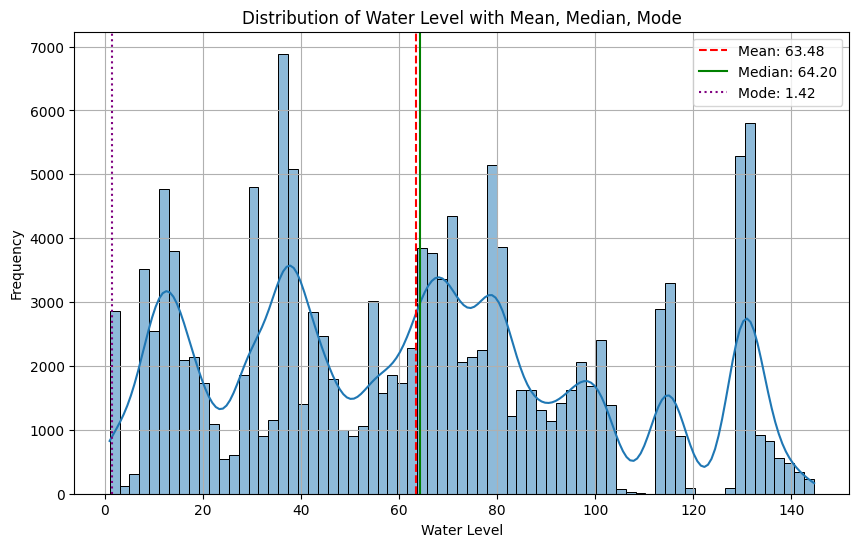

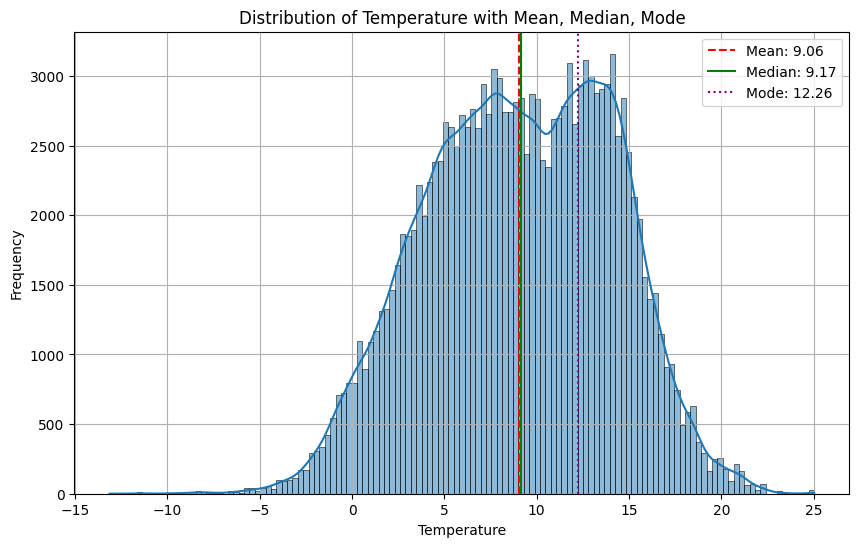

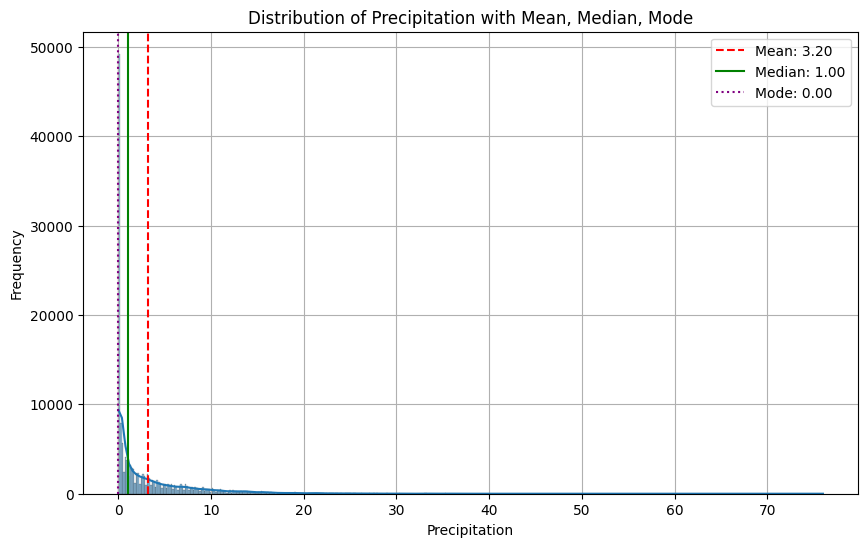

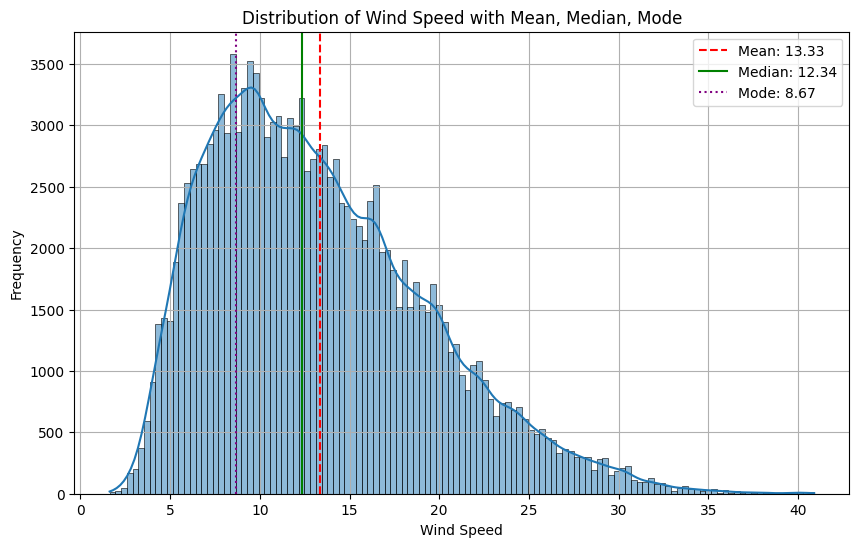

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in numerical_variables_to_plot:
    plt.figure(figsize=(10, 6))
    sns.histplot(dataset[col].dropna(), kde=True)

    # Calculate mean, median, and mode
    data_series = dataset[col].dropna()
    mean_val = data_series.mean()
    median_val = data_series.median()
    mode_val = data_series.mode()[0] if not data_series.mode().empty else None

    # Add vertical lines for mean, median, and mode
    plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')
    if mode_val is not None:
        plt.axvline(mode_val, color='purple', linestyle=':', label=f'Mode: {mode_val:.2f}')

    plt.title(f'Distribution of {col.replace("_", " ").title()} with Mean, Median, Mode')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(True)
    plt.show()

**This indicates that the mean and median are almost the same exept for precipitation**